<a href="https://colab.research.google.com/github/7amokarim/breast-cancer-detection-system/blob/main/cnn_2_classifcation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import os

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

print(os.listdir(dataset_path))

['malignant', 'normal', 'benign']


In [78]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [79]:
import os
import cv2
import numpy as np

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

IMG_SIZE = 224

X = []
y = []

for category in ["benign", "malignant"]:   # 👈 مفيش normal
    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):

        if not file.endswith(".png"):
            continue

        if "_mask" in file:   # 🔥 مهم جدًا
            continue

        img_path = os.path.join(path, file)

        # 👇 تعديل مهم
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # 👇 نحول لـ 3 channels
        img = np.stack((img,)*3, axis=-1)

        X.append(img)

        if category == "benign":
            y.append(0)
        else:
            y.append(1)

X = np.array(X, dtype=np.float32) / 255.0   # 🔥 normalize صح
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)

X: (647, 224, 224, 3)
y: (647,)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 مهم جدًا
)

print("Train:", np.bincount(y_train))
print("Test:", np.bincount(y_test))

Train: [349 168]
Test: [88 42]


In [81]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [82]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [83]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [84]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 943ms/step - accuracy: 0.6905 - loss: 0.6038 - val_accuracy: 0.7308 - val_loss: 0.5506
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 880ms/step - accuracy: 0.7621 - loss: 0.4947 - val_accuracy: 0.7462 - val_loss: 0.5037
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 884ms/step - accuracy: 0.8085 - loss: 0.4373 - val_accuracy: 0.7692 - val_loss: 0.4758
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 874ms/step - accuracy: 0.8337 - loss: 0.3987 - val_accuracy: 0.7154 - val_loss: 0.4803
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 958ms/step - accuracy: 0.8433 - loss: 0.3664 - val_accuracy: 0.8077 - val_loss: 0.4227
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8665 - loss: 0.3432 - val_accuracy: 0.8385 - val_loss: 0.4089
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 951ms/step - accuracy: 0.8704 - loss: 0.3194 - val_accuracy: 0.8538 - val_loss: 0.3828
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 848ms/step - accuracy: 0.8897 - loss: 0.3000 - val_accurac

In [85]:
print("Benign:", np.sum(y == 0))
print("Malignant:", np.sum(y == 1))

Benign: 437
Malignant: 210


In [86]:
print("Train distribution:", np.bincount(y_train))
print("Test distribution:", np.bincount(y_test))

Train distribution: [349 168]
Test distribution: [88 42]


In [87]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Pred unique:", np.unique(y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
Pred unique: [0 1]


In [88]:
print(np.unique(y))

[0 1]


In [89]:
print("X min:", X.min(), "X max:", X.max())
print("Unique labels:", np.unique(y))

X min: 0.0 X max: 1.0
Unique labels: [0 1]


In [90]:
loss, acc = model_type.evaluate(X_test, y_test)
print("Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 812ms/step - accuracy: 0.7077 - loss: 4.6936
Accuracy: 0.7076923251152039


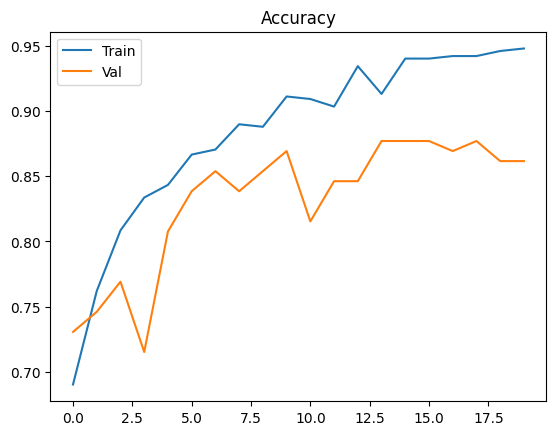

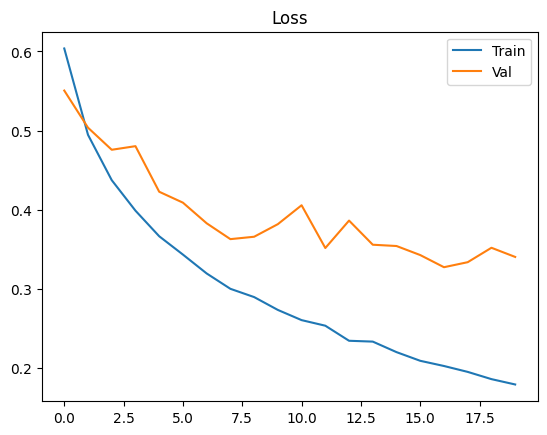

In [91]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


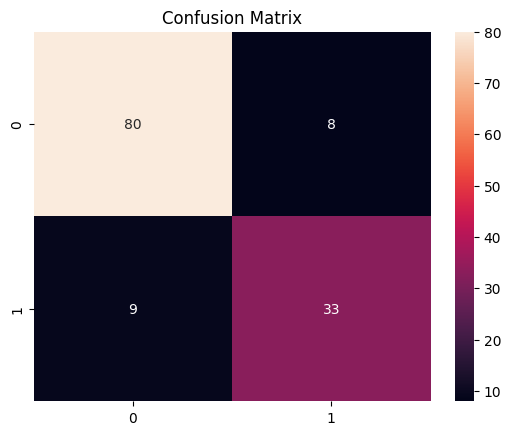

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction: Benign
True: Malignant


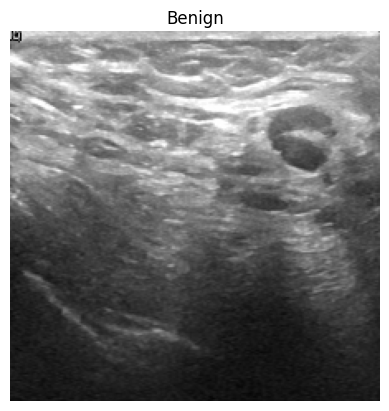

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Prediction: Malignant
True: Malignant


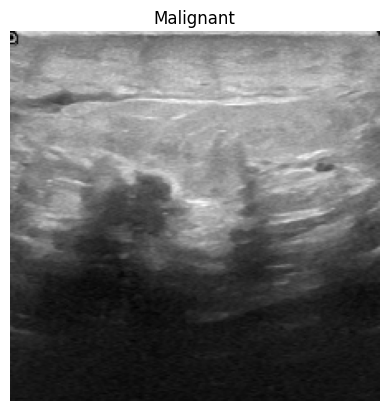

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Prediction: Benign
True: Malignant


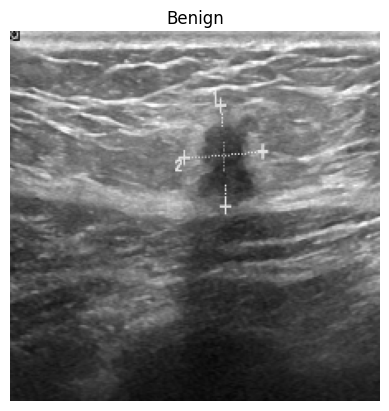

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction: Benign
True: Benign


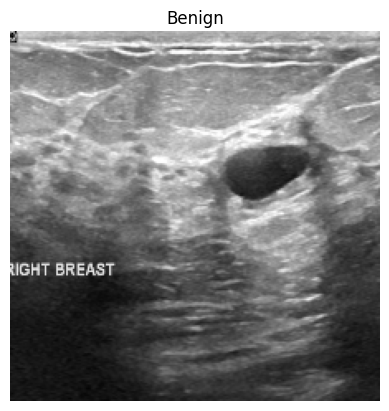

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction: Benign
True: Malignant


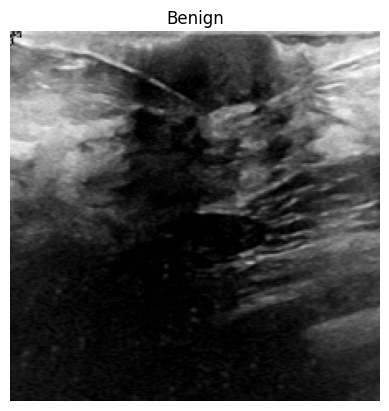

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediction: Benign
True: Benign


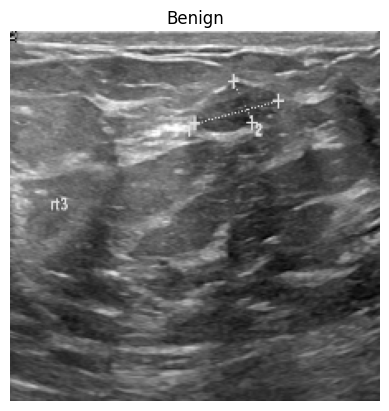

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediction: Benign
True: Benign


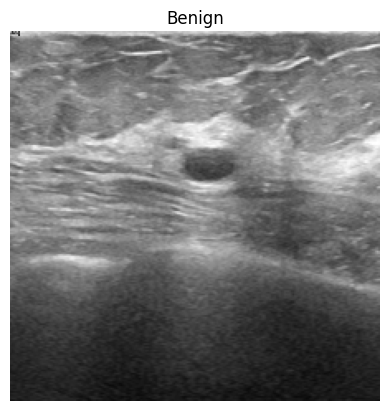

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Prediction: Malignant
True: Malignant


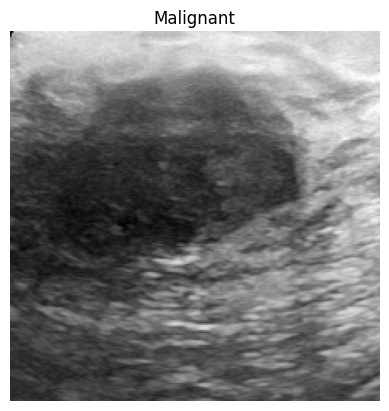

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction: Malignant
True: Malignant


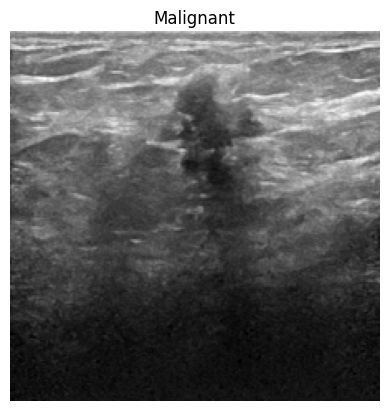

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Prediction: Malignant
True: Malignant


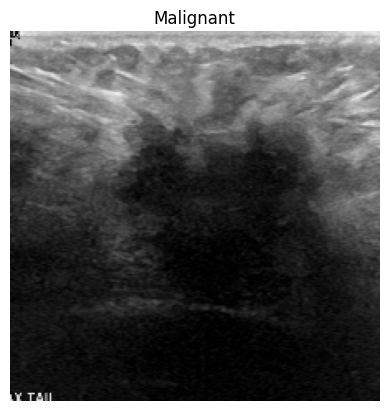

In [93]:
for i in range(10):
    sample = X_test[i].reshape(1,224,224,3)

    pred = model.predict(sample)[0][0]

    label = "Malignant" if pred > 0.5 else "Benign"

    print("Prediction:", label)
    print("True:", "Malignant" if y_test[i] == 1 else "Benign")

    plt.imshow(X_test[i])
    plt.title(label)
    plt.axis("off")
    plt.show()

In [94]:
model_type.save("/content/drive/MyDrive/cnn_benign_malignant.keras")

In [95]:
from google.colab import files

files.download("cnn_benign_malignant.keras")

FileNotFoundError: Cannot find file: cnn_benign_malignant.keras